In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import datetime as dt
from datetime import datetime
from pandas_datareader import data as pdr
import missingno as msno
#pd.set_option('display.max_rows', None)
#pd.set_option('display.float_format', lambda x: '%.3f' % x)
#pd.reset_option("all")
#pd.options.display.float_format = '{:,}'.format
sns.set_theme(rc={'figure.figsize':(11.7,6.5)})


# Collection

In [2]:
series = {
    "CPIAUCSL": "cpi",
    "PAYEMS": "nonfarm_unemployment",
    "MORTGAGE30US": "30yr_mortgage",
    "MORTGAGE15US": "15yr_mortgage",
    "UNRATENSA": "unemployment_rate",
    "UNRATE": "unemployment_rate",
    "FEDFUNDS": "fed_funds",
    "DRCLACBS":"delinquencies",
    "GS10": "ten_year",
    "GS2": "two_year",
    "GDPC1": "real_gdp",
    "OPHNFB": "labor_productivity",
    "ULCNFB": "unit_labor_cost",
    "ECIWAG": "wage_index",
    "INDPRO": "industrial_production",
    "RSAFS": "retail_sales",
    "RPI": "real_pi",
   
}

dfs = []
for code, name in series.items():
    s = pdr.get_data_fred(code, start="1990-01-01")
    s = s.rename(columns={code: name})
    dfs.append(s)

df = pd.concat(dfs, axis=1).resample("D").mean()
df["inflation_yoy"] = df["cpi"].pct_change(4) * 100
df["wage_growth_yoy"] = df["wage_index"].pct_change(4) * 100
df["real_wage_growth"] = df["wage_growth_yoy"] - df["inflation_yoy"]

<Axes: >

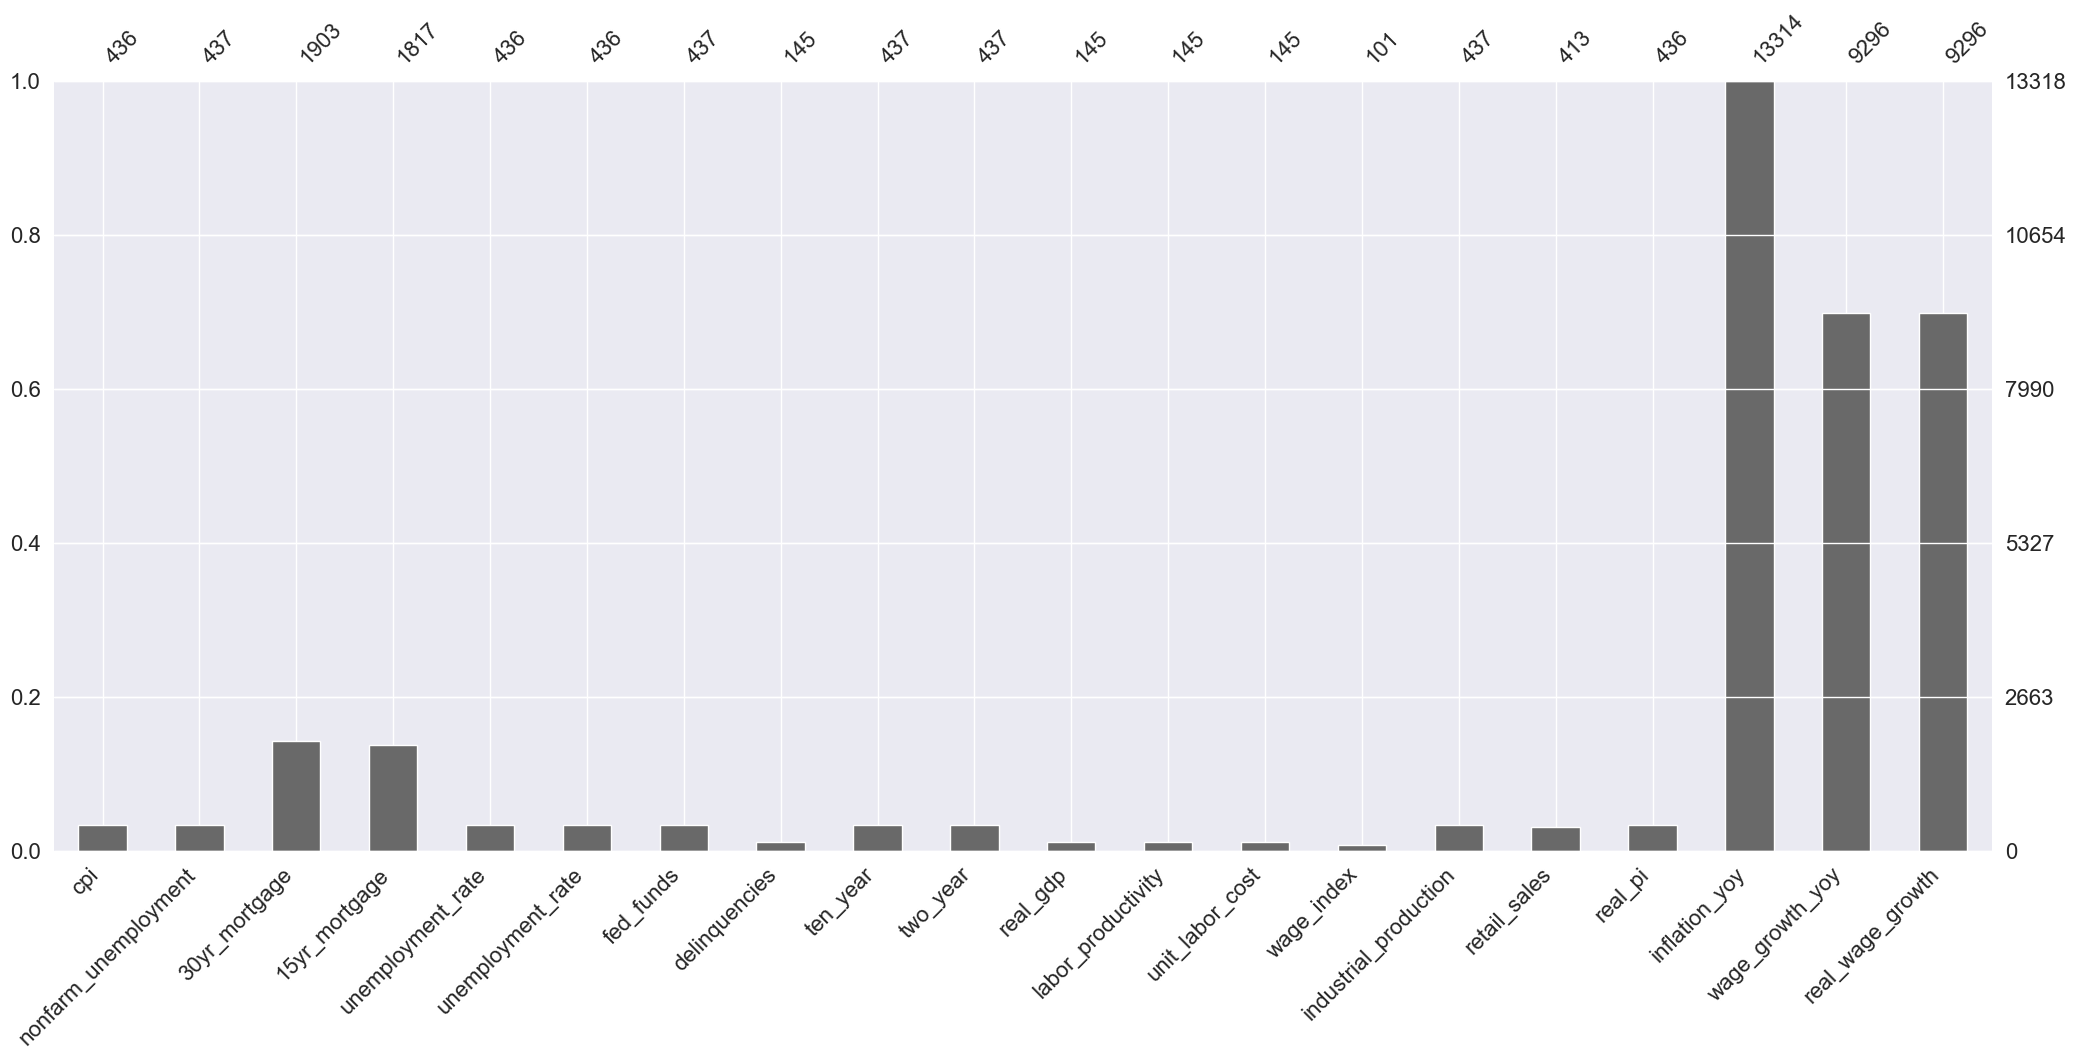

In [8]:
sns.set_theme(rc={'figure.figsize':(11.7,4)})
#%matplotlib inline
msno.bar(df)

In [11]:
df.inflation_yoy.isna().sum()

4

In [14]:
df.wage_growth_yoy.isna().sum()

4022

In [15]:
df.shape

(13318, 20)

In [10]:
df.head()

,cpi,nonfarm_unemployment,30yr_mortgage,15yr_mortgage,unemployment_rate,unemployment_rate,fed_funds,delinquencies,ten_year,two_year,real_gdp,labor_productivity,unit_labor_cost,wage_index,industrial_production,retail_sales,real_pi,inflation_yoy,wage_growth_yoy,real_wage_growth
DATE,,,,,,,,,,,,,,,,,,,,
1990-01-01,127.5,"109,196.0",NaN,NaN,6.0,5.4,8.23,3.6,8.21,8.09,"10,047.386",57.936,70.319,NaN,61.729,NaN,"8,170.022",NaN,NaN,NaN
1990-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-05,NaN,NaN,9.83,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN


In [6]:
#dim date
start = "1900-01-01"
end = pd.Timestamp.today().normalize()  # or "today"
months = pd.date_range(start=start, end=end, freq="D")  # month starts

dim_date = pd.DataFrame({"month": months})
dim_date["month_str"] = dim_date["month"].dt.strftime("%Y-%m")

In [11]:
df_long = pd.melt(
    df, 
    id_vars=['month','month_str'], 
    value_vars=df.columns[2:],
    var_name='metric', 
    value_name='rate'
)

In [12]:
df_long.head()

,month,month_str,metric,rate
0,1900-01-01,1900-01,inflation_rt,NaN
1,1900-01-02,1900-01,inflation_rt,NaN
2,1900-01-03,1900-01,inflation_rt,NaN
3,1900-01-04,1900-01,inflation_rt,NaN
4,1900-01-05,1900-01,inflation_rt,NaN


# Visualization

In [13]:
df_long.metric.unique()

array(['inflation_rt', 'employment_nonfarm', 'thirty_yr_rt',
       'fifteen_yr_rt', 'fedfunds_rt', 'unemployment_rt',
       'delinquencies_rt', 'gdp', '10yr_treasury_rt', '2yr_treasury_rt',
       'labor_productivity', 'unit_labor_cost', 'industrial_production',
       'retail_sales', 'real_pi', 'wage_growth'], dtype=object)

<Axes: xlabel='month', ylabel='rate'>

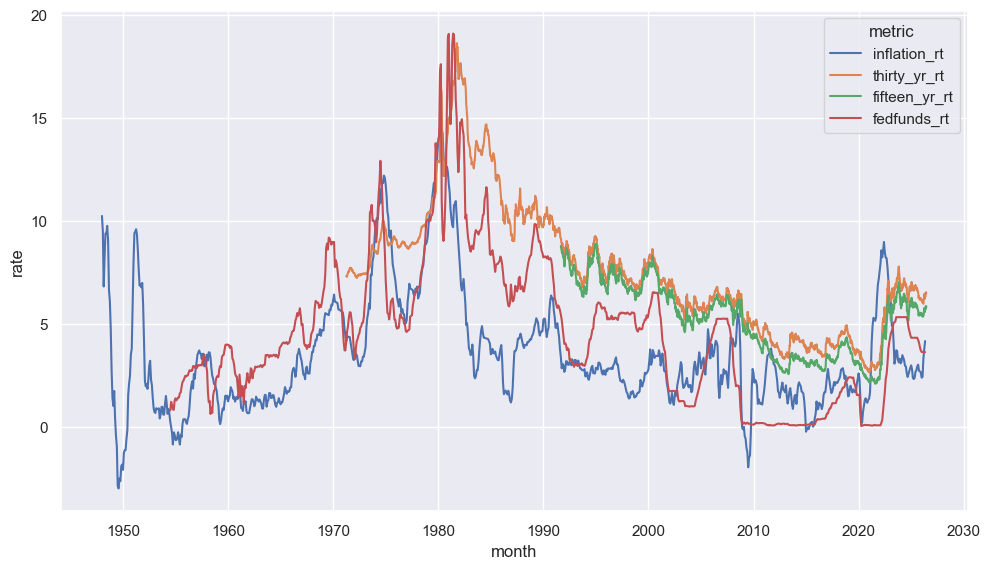

In [ ]:

x = df_long.copy()
allowed_metrics = ['inflation_rt','fedfunds_rt','thirty_yr_rt','fifteen_yr_rt']
x = x[x['metric'].isin(allowed_metrics)]
sns.lineplot(x, x='month', y='rate', hue='metric')

<Axes: xlabel='month', ylabel='rate'>

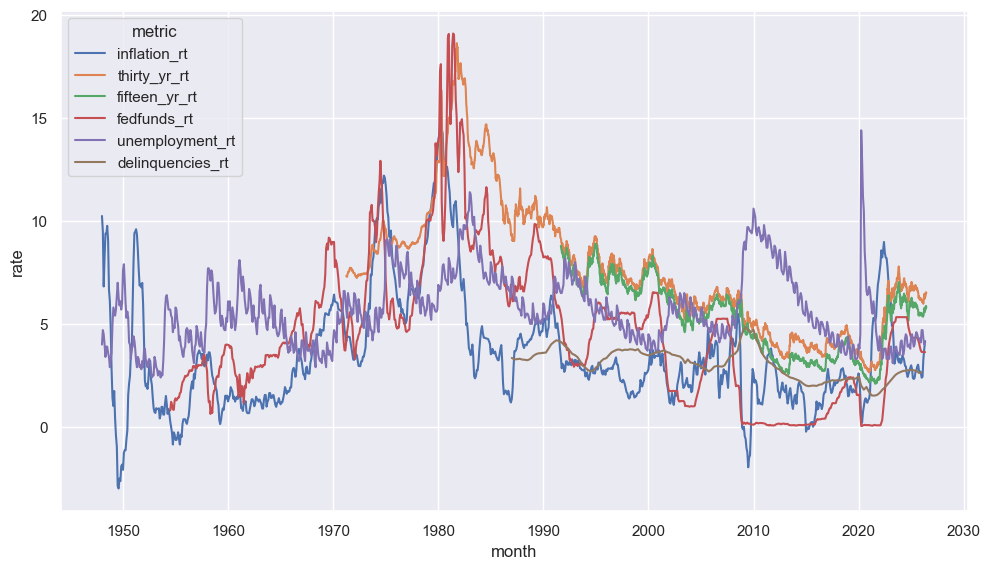

In [23]:
x = df_long.copy()
allowed_metrics = ['inflation_rt', 'thirty_yr_rt',
       'fedfunds_rt', 'unemployment_rt', 'delinquencies_rt','fifteen_yr_rt']
x = x[x['metric'].isin(allowed_metrics)]
sns.lineplot(x, x='month', y='rate', hue='metric')

In [16]:
df.columns

Index(['month', 'month_str', 'inflation_rt', 'employment_nonfarm',
       'thirty_yr_rt', 'fifteen_yr_rt', 'fedfunds_rt', 'unemployment_rt',
       'delinquencies_rt', 'gdp', '10yr_treasury_rt', '2yr_treasury_rt',
       'labor_productivity', 'unit_labor_cost', 'industrial_production',
       'retail_sales', 'real_pi', 'wage_growth'],
      dtype='object')

<Axes: xlabel='month', ylabel='rate'>

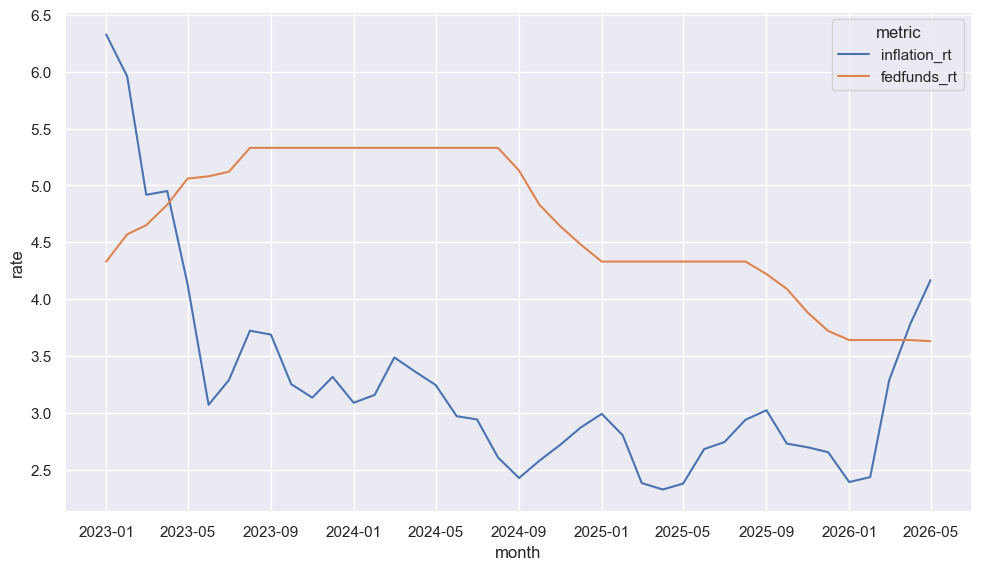

In [25]:
x = df_long.copy()
allowed_metrics = ['fedfunds_rt','inflation_rt']
x = x[x['metric'].isin(allowed_metrics)]
sns.lineplot(x[x['month']>='2023-01-01'], x='month', y='rate', hue='metric')

<Axes: xlabel='month', ylabel='rate'>

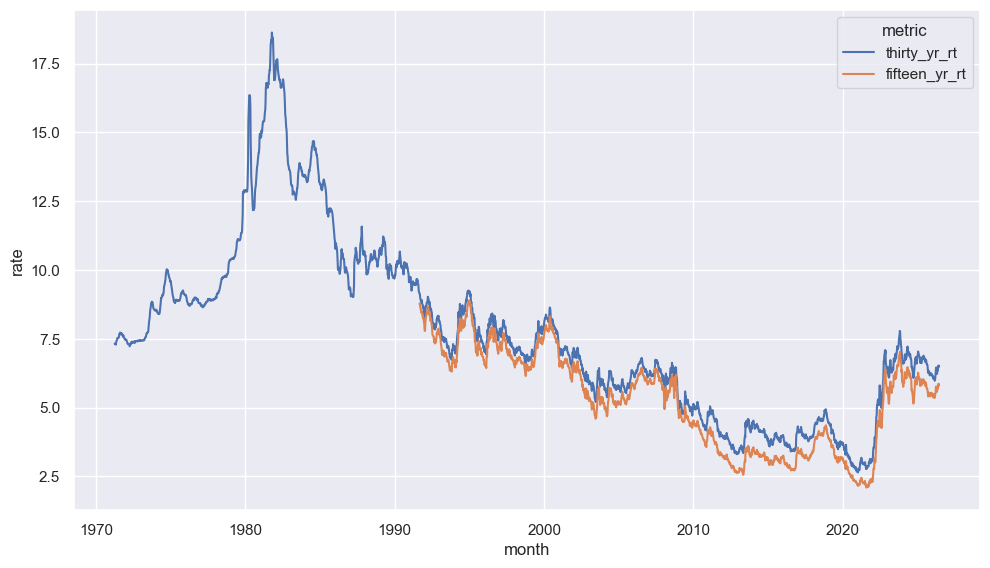

In [24]:
x = df_long.copy()
allowed_metrics = ['thirty_yr_rt','fifteen_yr_rt']
x = x[x['metric'].isin(allowed_metrics)]
sns.lineplot(x, x='month', y='rate', hue='metric')

<Axes: >

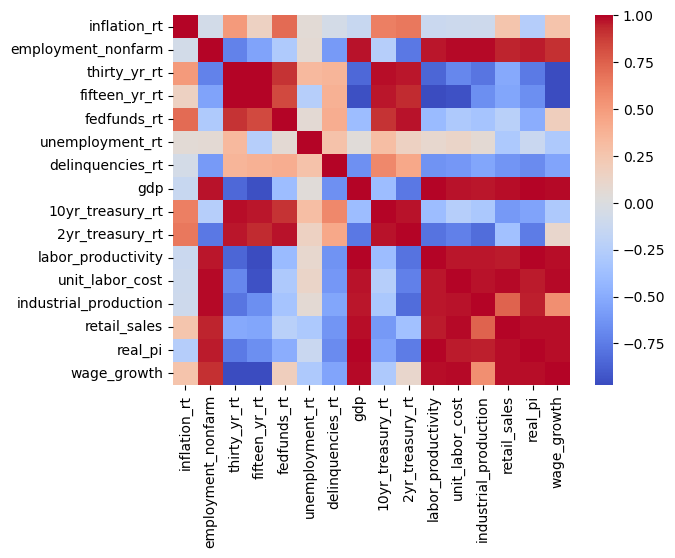

In [20]:
sns.heatmap(df.iloc[:,2:].corr(), cmap='coolwarm')

In [21]:
employed = pd.DataFrame(fred.get_series('PAYEMS')).reset_index() #mortgage rates
employed['employed_difference'] = employed[0] - employed[0].shift(1)
employed['employed_difference'] = employed['employed_difference']*1000
employed.columns = ['date','employed','employed_difference']

NameError: name 'fred' is not defined

In [ ]:
delinquencies

In [ ]:
fred.search('PAYEMS').head(5)